# Multivariate Statistics — Final Project
**Hipparcos Star Catalog**

## Variable Descriptions
- **HIP**: Hipparcos star number (ID — not used in analysis)
- **Vmag**: Visual band magnitude (brightness, inverted log scale)
- **RA**: Right Ascension in degrees (sky longitude)
- **DE**: Declination in degrees (sky latitude)
- **Plx**: Parallax in milliarcseconds — 1000/Plx gives distance in parsecs
- **pmRA**: Proper motion in RA direction (mas/yr)
- **pmDE**: Proper motion in Declination direction (mas/yr)
- **e_Plx**: Measurement error in parallax (mas)
- **B-V**: Color index — proxy for stellar surface temperature


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

## 2. Load & Describe Data

In [2]:
df = pd.read_csv('HIP_star.dat', sep=r'\s+')
print(f'Shape: {df.shape}')
df.info()

Shape: (2719, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2719 entries, 0 to 2718
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HIP     2719 non-null   int64  
 1   Vmag    2719 non-null   float64
 2   RA      2719 non-null   float64
 3   DE      2719 non-null   float64
 4   Plx     2719 non-null   float64
 5   pmRA    2719 non-null   float64
 6   pmDE    2719 non-null   float64
 7   e_Plx   2719 non-null   float64
 8   B-V     2678 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 191.3 KB


In [3]:
summary_df = df.describe().round(3)
summary_df.to_csv('data_summary.csv', index=True)

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

summary_df = df.describe().round(3).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

table = ax.table(cellText=summary_df.values,
                 colLabels=summary_df.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.savefig('summary_table.png', bbox_inches='tight', dpi=300)
plt.close()

### Missing Values

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print(f"\nB-V missing: {df['B-V'].isna().sum()} ({df['B-V'].isna().mean()*100:.1f}%)")

df.dropna(inplace=True)
print(f'\nShape after dropping NaNs: {df.shape}')

Missing values per column:
HIP       0
Vmag      0
RA        0
DE        0
Plx       0
pmRA      0
pmDE      0
e_Plx     0
B-V      41
dtype: int64

B-V missing: 41 (1.5%)

Shape after dropping NaNs: (2678, 9)


## 3. Scatter Plot Matrix (Pairplot)
Visualizing pairwise relationships between all variables. HIP is excluded as it is just an identifier.

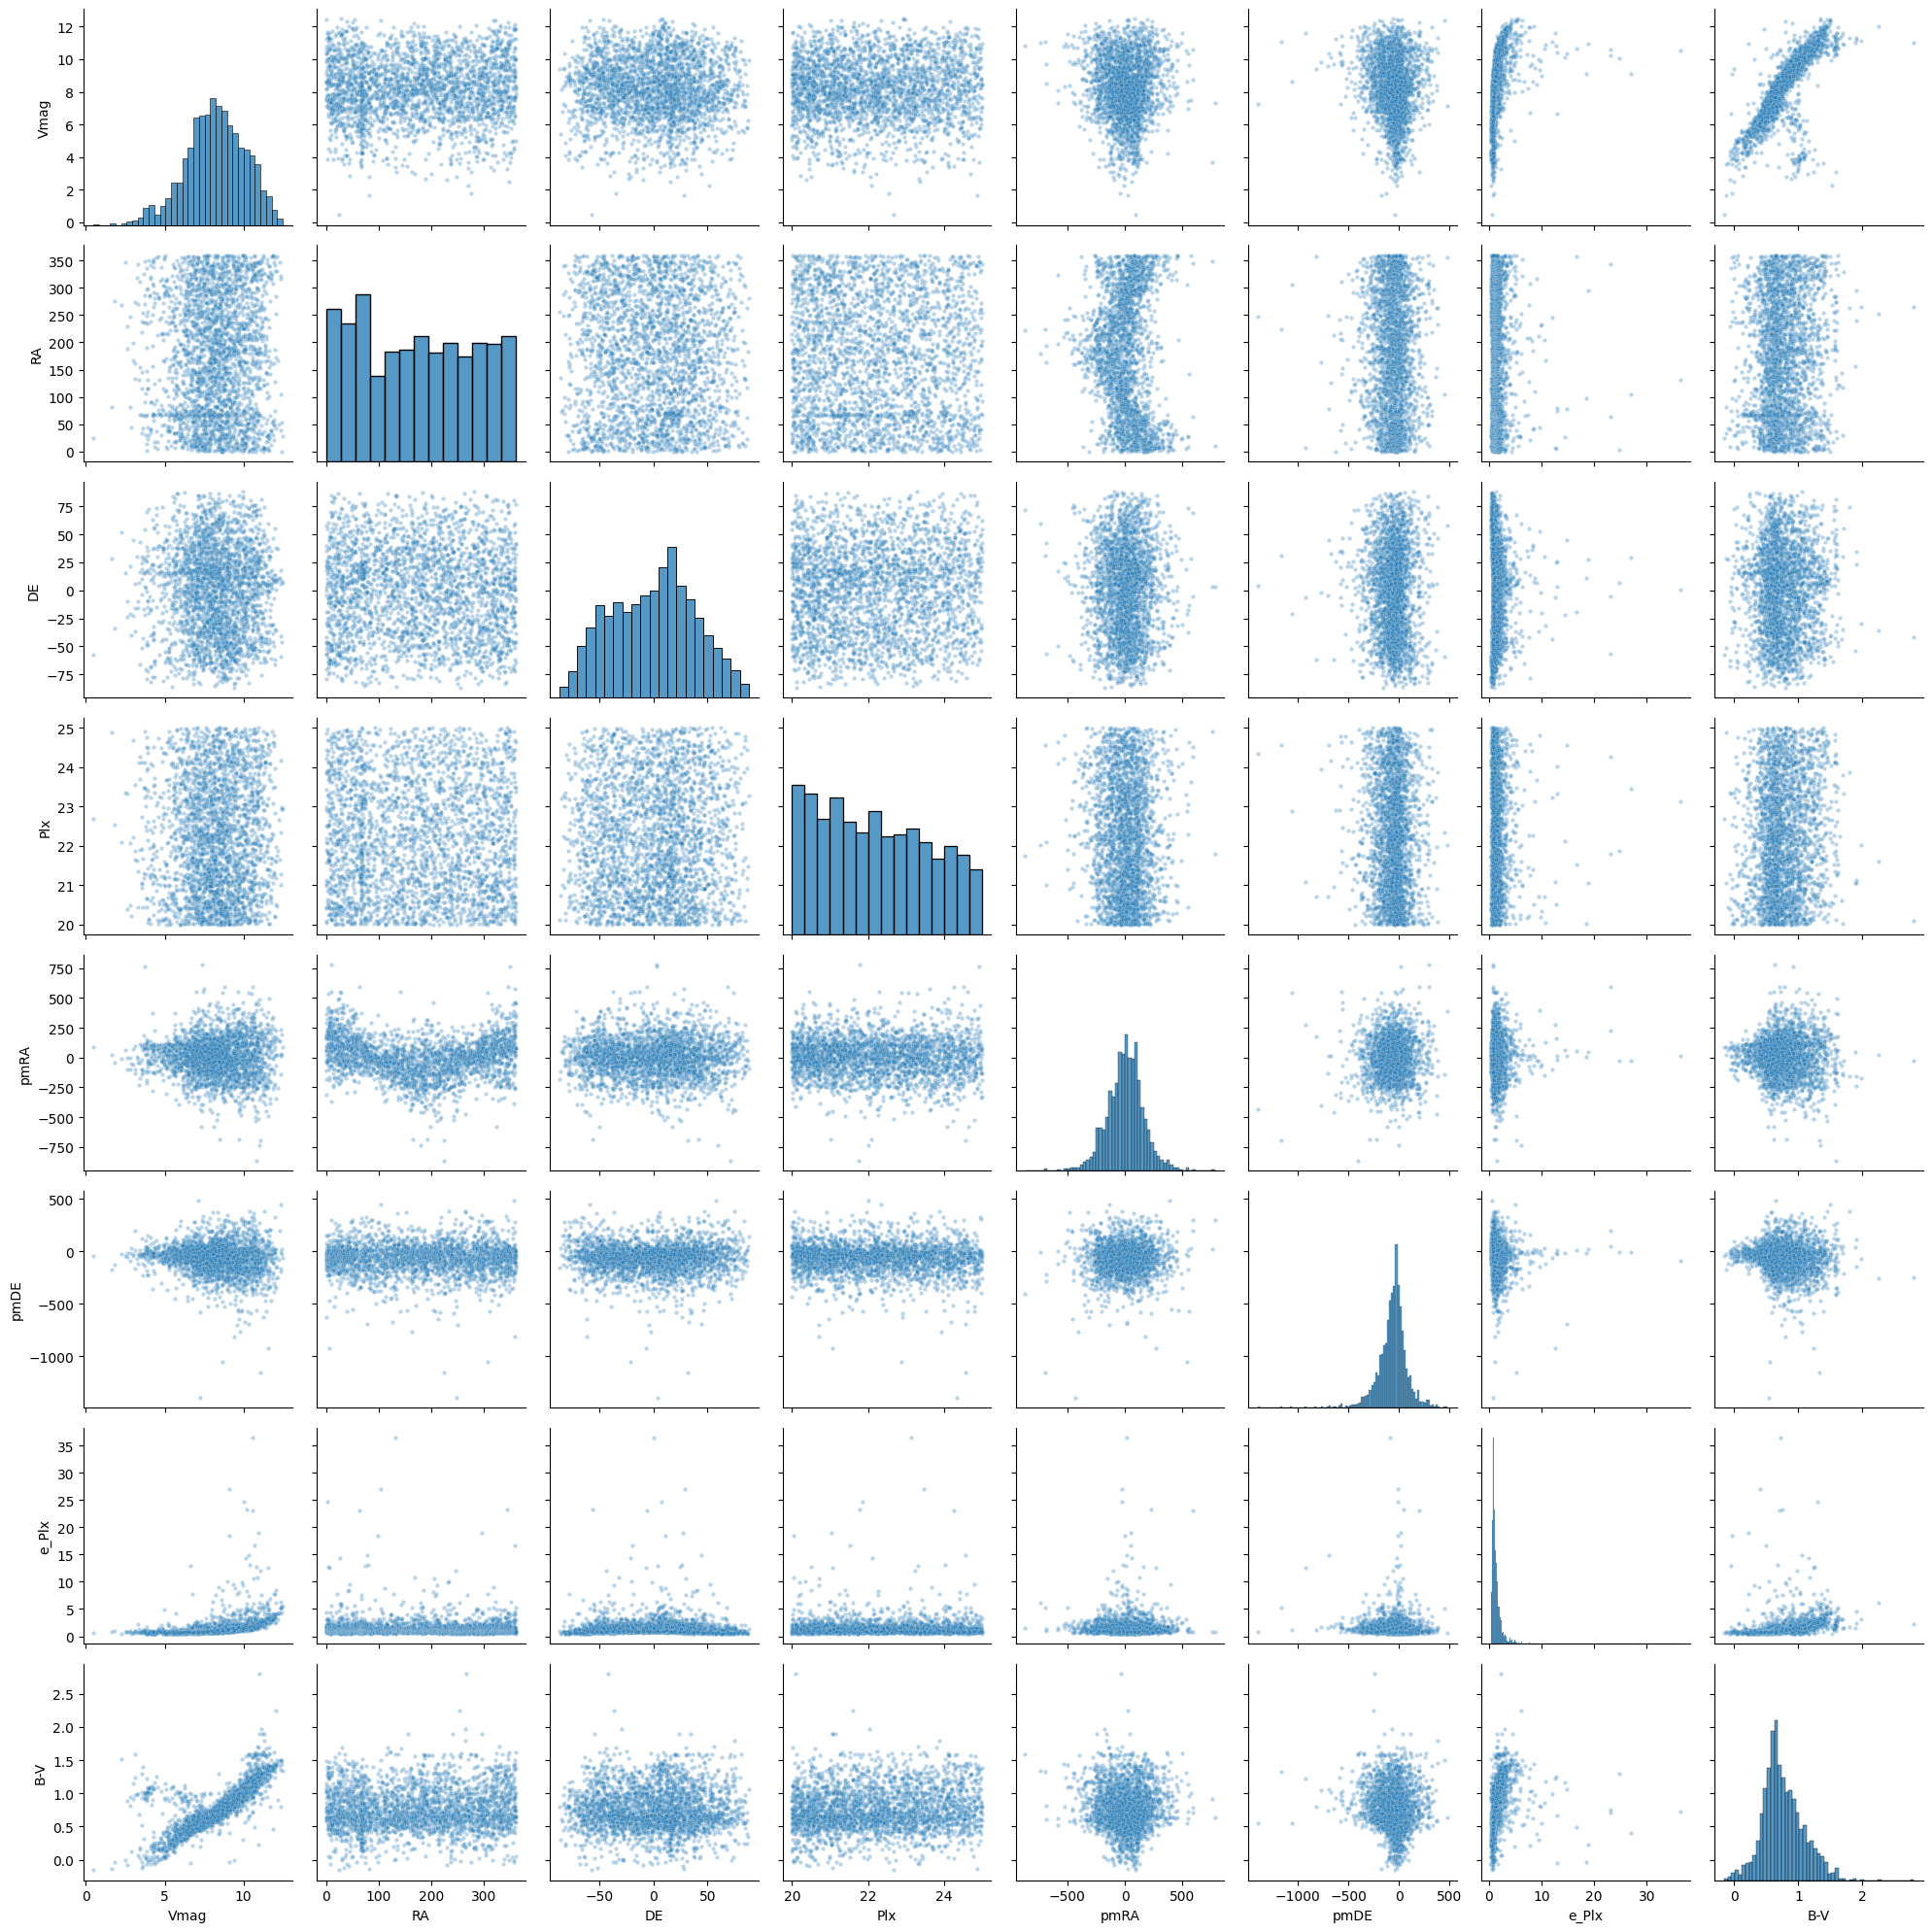

In [6]:
df_plot = df.drop(columns=['HIP'])

sns.pairplot(
    df_plot,
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='hist'
)
plt.tight_layout()
plt.savefig('scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Normality Assessment
### 4a. Histograms

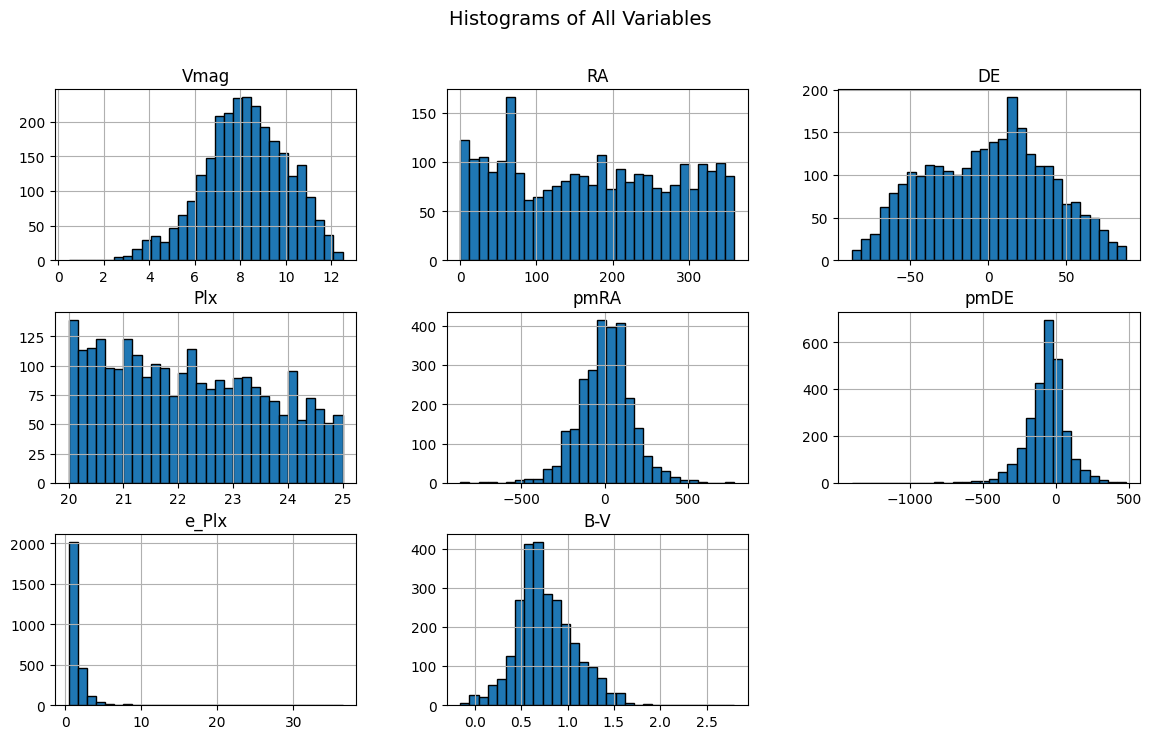

In [7]:
df_plot.hist(figsize=(14, 8), bins=30, edgecolor='black')
plt.suptitle('Histograms of All Variables', fontsize=14)
plt.show()

### 4b. QQ-Plots

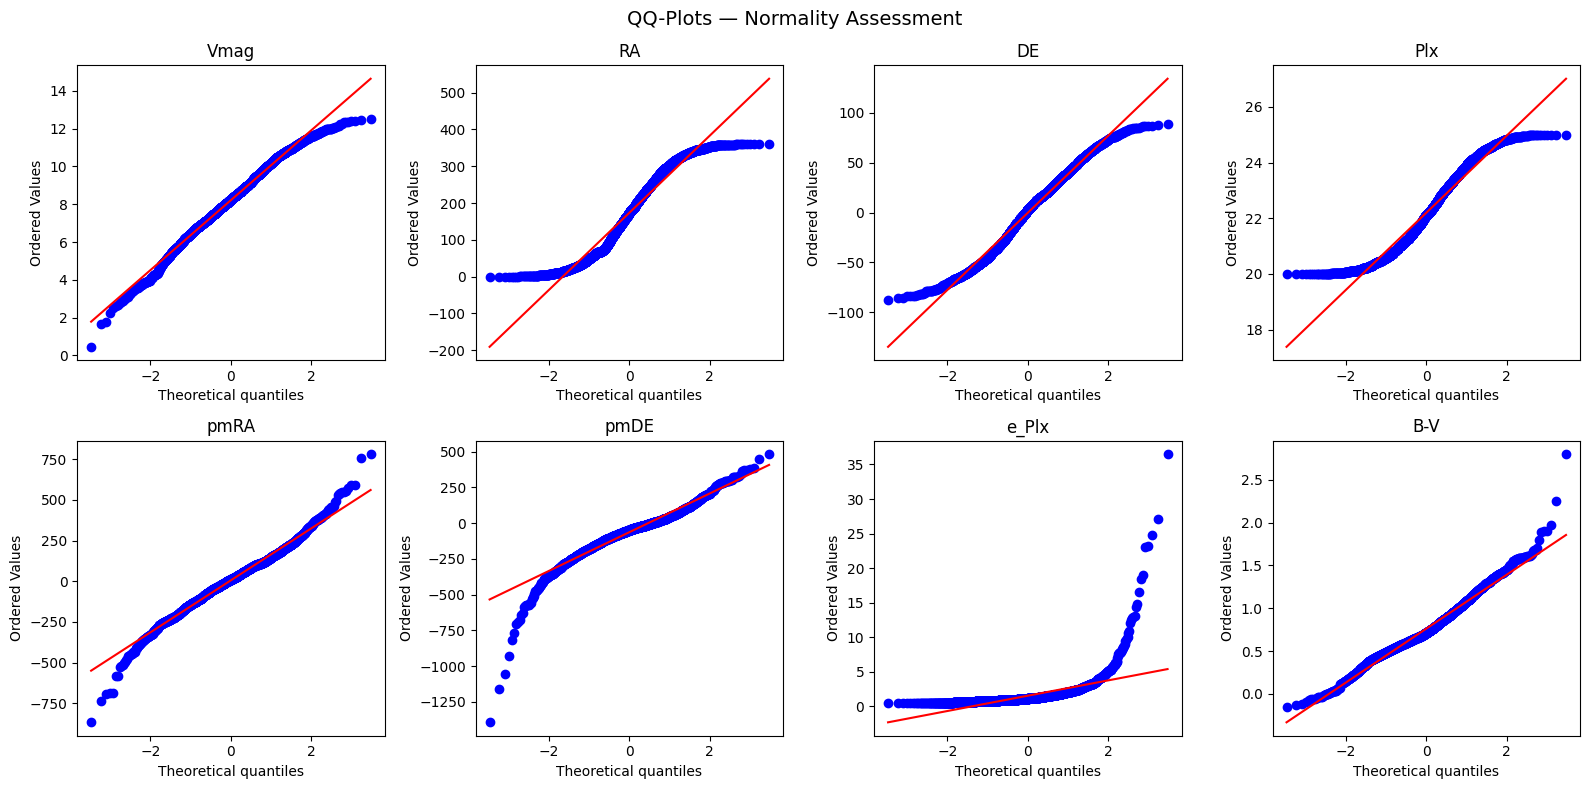

In [8]:
cols = ['Vmag', 'RA', 'DE', 'Plx', 'pmRA', 'pmDE', 'e_Plx', 'B-V']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cols):
    stats.probplot(df[col].dropna(), plot=ax)
    ax.set_title(col)
plt.suptitle('QQ-Plots — Normality Assessment', fontsize=14)
plt.tight_layout()
plt.show()

### 4c. Boxplots (Outlier Detection)

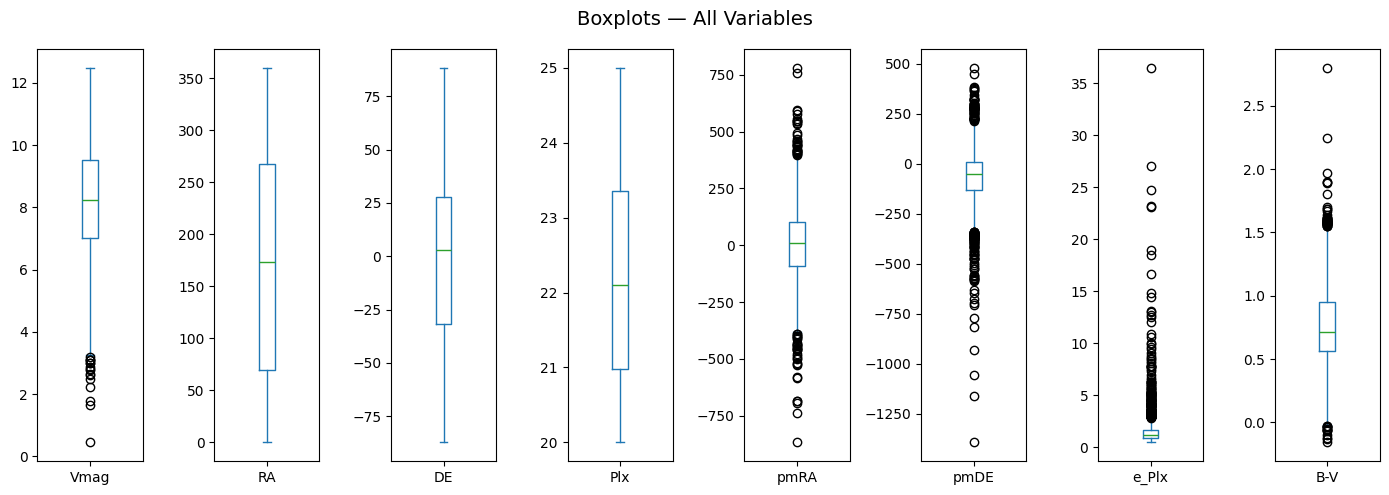

In [9]:
df_plot.plot(kind='box', subplots=True, sharex=False, sharey=False, figsize=(14, 5))
plt.suptitle('Boxplots — All Variables', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Linear Regression
**Target variable: Vmag** (visual brightness)

Vmag is chosen because it has clear physical predictors: distance (Plx) and temperature (B-V). Predicting brightness from these variables essentially recovers the distance-luminosity relationship — one of the fundamental laws in stellar astrophysics.

In [10]:
FEATURES = ['RA', 'DE', 'Plx', 'pmRA', 'pmDE', 'e_Plx', 'B-V']
TARGET = 'Vmag'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)

coef_df = pd.DataFrame({'Variable': FEATURES, 'Coefficient': lr.coef_})
coef_df['abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('abs', ascending=False).drop(columns='abs')
print(f'Intercept: {lr.intercept_:.4f}')
print(coef_df.to_string(index=False))

Intercept: 8.2017
Variable  Coefficient
     B-V     1.333435
   e_Plx     0.375505
     Plx    -0.079684
      RA    -0.050960
    pmDE    -0.037349
      DE    -0.034480
    pmRA    -0.010160


In [11]:
rmse = root_mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f'RMSE : {rmse:.4f}')
print(f'MAE  : {mae:.4f}')
print(f'R²   : {r2:.4f}')

RMSE : 1.1665
MAE  : 0.7274
R²   : 0.6127


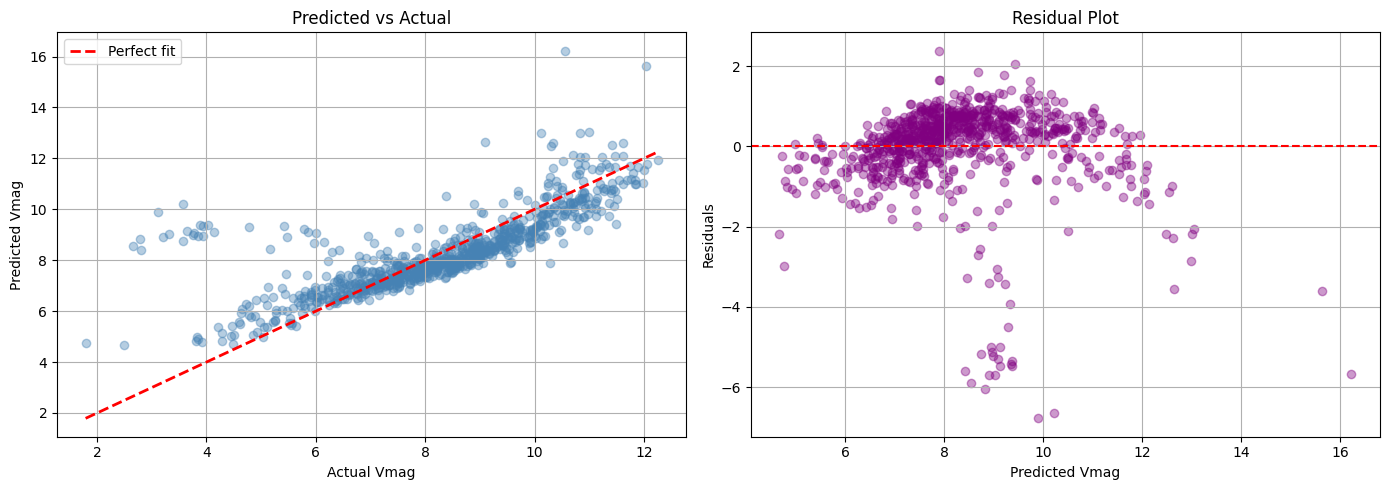

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
perfect = np.linspace(y_test.min(), y_test.max(), 100)
axes[0].plot(perfect, perfect, 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual Vmag')
axes[0].set_ylabel('Predicted Vmag')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True)

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='purple')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Vmag')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('my_regression_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Variable Selection (LASSO)
LASSO (Least Absolute Shrinkage and Selection Operator) penalizes large coefficients, automatically shrinking irrelevant variables to zero. Cross-validation is used to find the optimal regularization strength (alpha).

In [13]:
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_train_sc, y_train)

lasso_coef = pd.DataFrame({
    'Variable': FEATURES,
    'LASSO Coefficient': lasso.coef_
}).sort_values('LASSO Coefficient', key=abs, ascending=False)

print(f'Best alpha (regularization strength): {lasso.alpha_:.6f}')
print('\nCoefficients (0 = eliminated by LASSO):')
print(lasso_coef.to_string(index=False))

selected = lasso_coef[lasso_coef['LASSO Coefficient'] != 0]['Variable'].tolist()
eliminated = lasso_coef[lasso_coef['LASSO Coefficient'] == 0]['Variable'].tolist()
print(f'\nSelected variables : {selected}')
print(f'Eliminated variables: {eliminated}')

Best alpha (regularization strength): 0.035576

Coefficients (0 = eliminated by LASSO):
Variable  LASSO Coefficient
     B-V           1.301011
   e_Plx           0.350427
     Plx          -0.038780
      RA          -0.009148
    pmDE          -0.003420
      DE          -0.000000
    pmRA          -0.000000

Selected variables : ['B-V', 'e_Plx', 'Plx', 'RA', 'pmDE']
Eliminated variables: ['DE', 'pmRA']


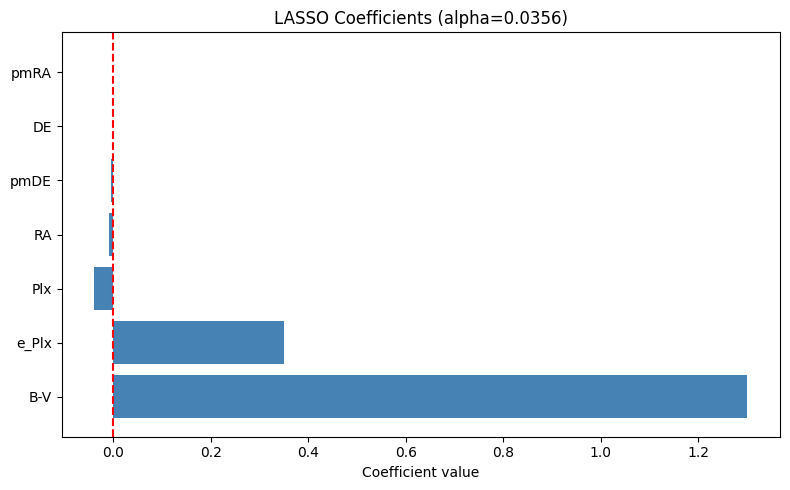

In [14]:
plt.figure(figsize=(8, 5))
colors = ['steelblue' if c != 0 else 'lightgray' for c in lasso_coef['LASSO Coefficient']]
plt.barh(lasso_coef['Variable'], lasso_coef['LASSO Coefficient'], color=colors)
plt.axvline(0, color='red', linestyle='--')
plt.title(f'LASSO Coefficients (alpha={lasso.alpha_:.4f})')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

## 7. Principal Component Analysis (PCA)

In [15]:
pca_features = ['Vmag', 'RA', 'DE', 'Plx', 'pmRA', 'pmDE', 'e_Plx', 'B-V']
X_pca = df[pca_features].dropna()

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA()
pca.fit(X_pca_scaled)

explained   = pca.explained_variance_ratio_
cumulative  = np.cumsum(explained)
eigenvalues = pca.explained_variance_

summary = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained))],
    'Eigenvalue': eigenvalues.round(4),
    'Explained Variance (%)': (explained * 100).round(2),
    'Cumulative (%)': (cumulative * 100).round(2)
})
print(summary.to_string(index=False))

 PC  Eigenvalue  Explained Variance (%)  Cumulative (%)
PC1      2.0456                   25.56           25.56
PC2      1.1520                   14.39           39.95
PC3      1.0726                   13.40           53.36
PC4      0.9652                   12.06           65.42
PC5      0.9283                   11.60           77.02
PC6      0.8618                   10.77           87.79
PC7      0.7652                    9.56           97.35
PC8      0.2123                    2.65          100.00


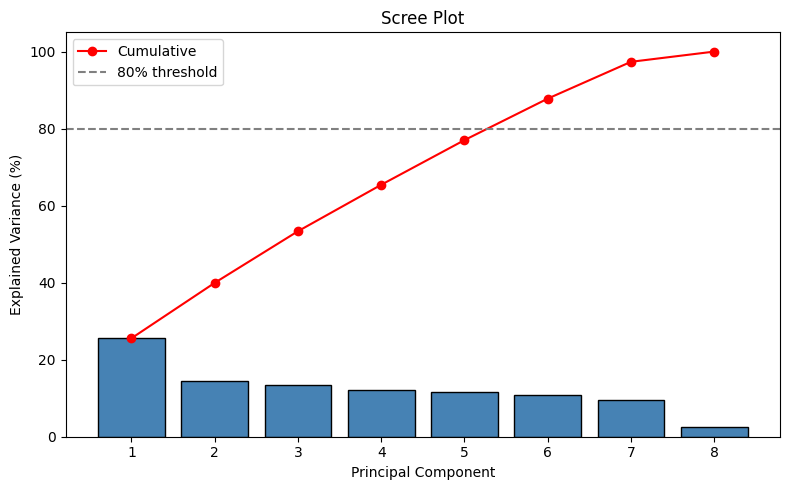

In [17]:
# Create a single plot instead of subplots
fig, ax = plt.subplots(figsize=(8, 5))

# Scree plot (changed axes[0] to ax)
ax.bar(range(1, len(explained)+1), explained*100, color='steelblue', edgecolor='black')
ax.plot(range(1, len(explained)+1), cumulative*100, 'ro-', label='Cumulative')
ax.axhline(80, color='gray', linestyle='--', label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot')
ax.legend()

plt.tight_layout()

plt.savefig('scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Correlation Circle
Arrows pointing in the same direction = positively correlated variables. Opposite directions = negatively correlated. Arrow length indicates how well the variable is represented by the first two PCs.

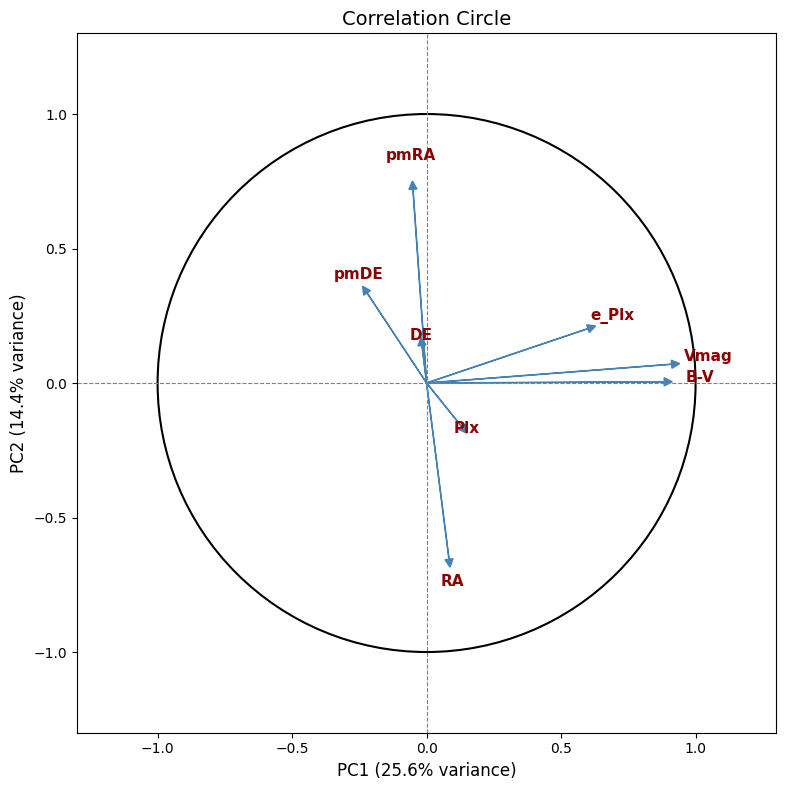

In [18]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(8, 8))
circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=1.5)
ax.add_patch(circle)

for i, var in enumerate(pca_features):
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
             head_width=0.03, head_length=0.03,
             fc='steelblue', ec='steelblue')
    ax.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15,
            var, fontsize=11, ha='center', color='darkred', fontweight='bold')

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Correlation Circle', fontsize=14)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

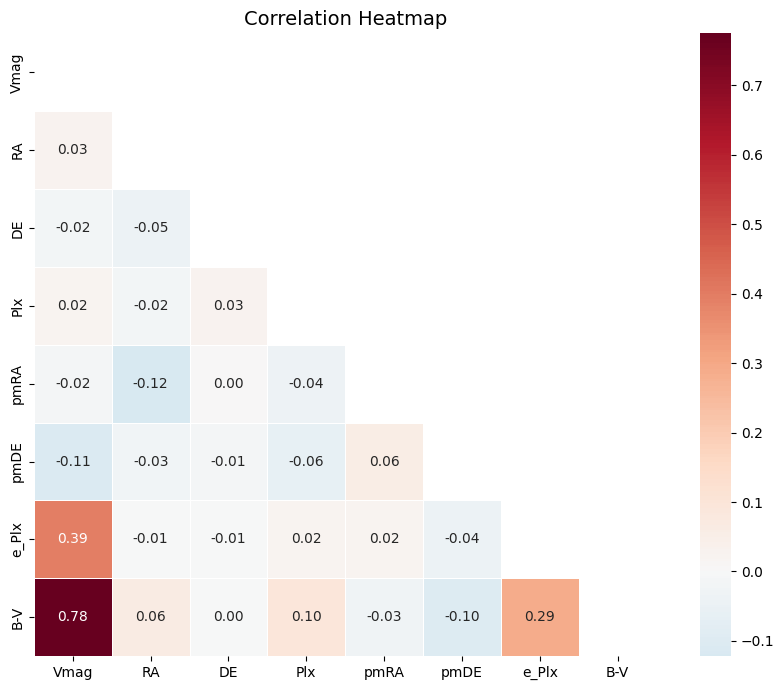

In [19]:
plt.figure(figsize=(9, 7))
corr = df[pca_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Projection of Stars onto First Two Principal Components
Each point is a star. Clusters in this space reveal structure — Hyades cluster members vs. background field stars.

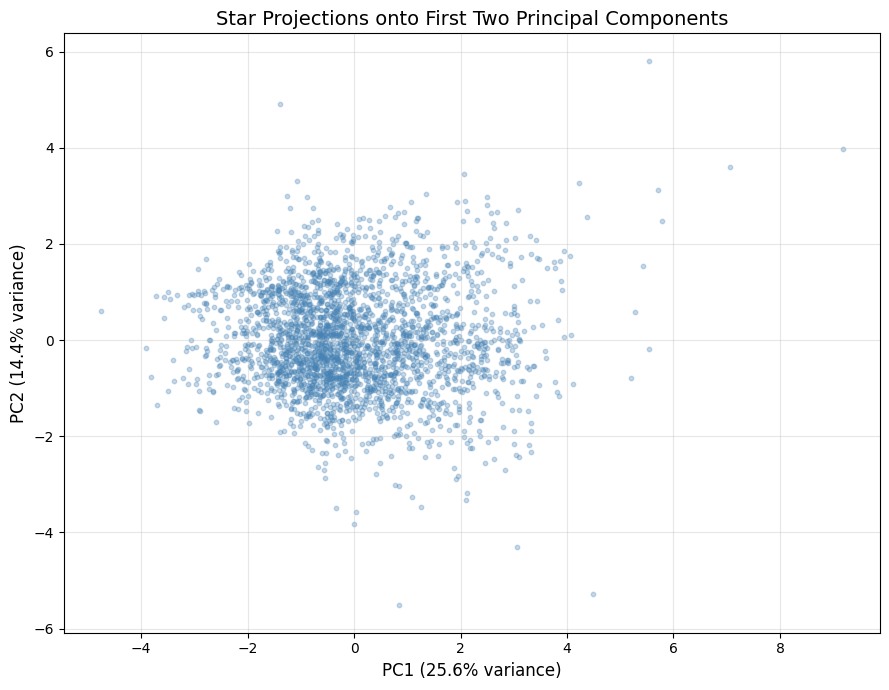

In [20]:
X_projected = pca.transform(X_pca_scaled)

plt.figure(figsize=(9, 7))
plt.scatter(X_projected[:, 0], X_projected[:, 1],
            alpha=0.3, s=10, color='steelblue')
plt.xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
plt.title('Star Projections onto First Two Principal Components', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Model Comparison ===
Metric       Linear Reg   RandomForest
--------------------------------------
RMSE             1.1665         0.7457
MAE              0.7274         0.4781
R²               0.6127         0.8417


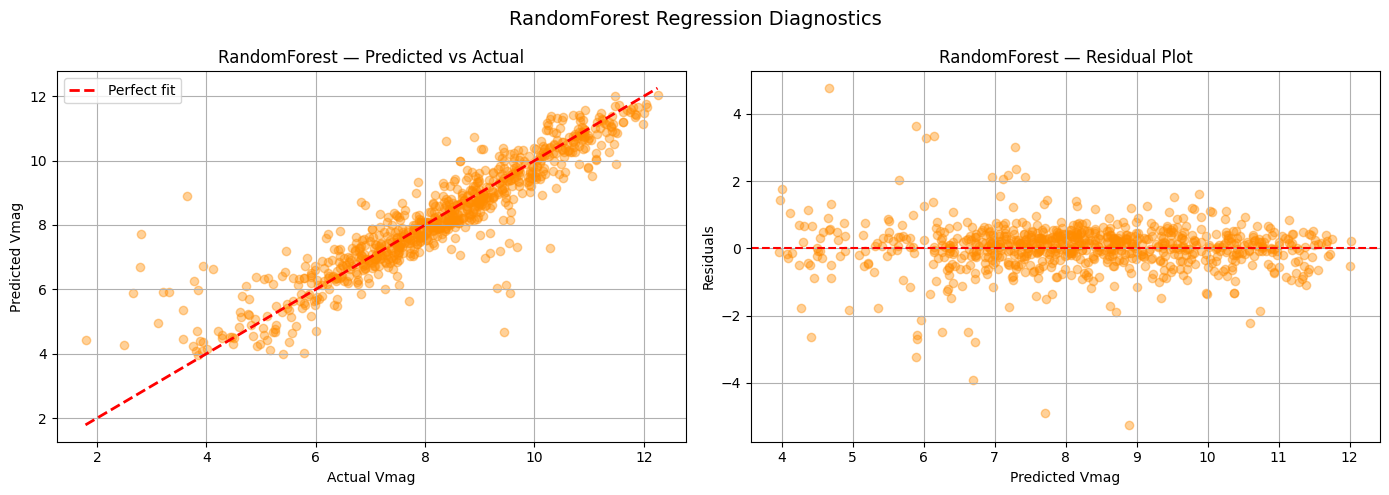

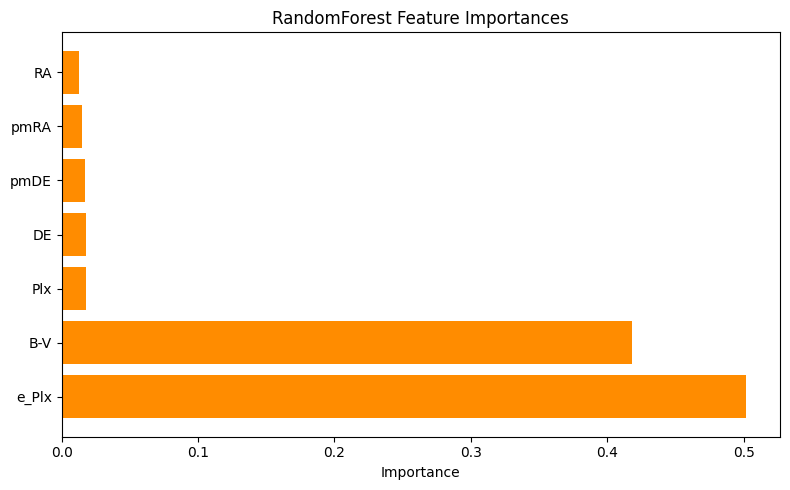


Feature Importances:
Variable  Importance
   e_Plx    0.501622
     B-V    0.418018
     Plx    0.017595
      DE    0.017561
    pmDE    0.017061
    pmRA    0.015188
      RA    0.012955


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Model Comparison ===')
print(f'{'Metric':<10} {'Linear Reg':>12} {'RandomForest':>14}')
print('-' * 38)
print(f'{'RMSE':<10} {rmse:>12.4f} {rmse_rf:>14.4f}')
print(f'{'MAE':<10} {mae:>12.4f} {mae_rf:>14.4f}')
print(f'{'R²':<10} {r2:>12.4f} {r2_rf:>14.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

perfect = np.linspace(y_test.min(), y_test.max(), 100)

axes[0].scatter(y_test, y_pred_rf, alpha=0.4, color='darkorange')
axes[0].plot(perfect, perfect, 'r--', linewidth=2, label='Perfect fit')
axes[0].set_xlabel('Actual Vmag')
axes[0].set_ylabel('Predicted Vmag')
axes[0].set_title('RandomForest — Predicted vs Actual')
axes[0].legend()
axes[0].grid(True)

residuals_rf = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.4, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Vmag')
axes[1].set_ylabel('Residuals')
axes[1].set_title('RandomForest — Residual Plot')
axes[1].grid(True)

plt.suptitle('RandomForest Regression Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

importances = pd.DataFrame({
    'Variable': FEATURES,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importances['Variable'], importances['Importance'], color='darkorange')
plt.title('RandomForest Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nFeature Importances:')
print(importances.to_string(index=False))